# Market Regime & Machine Learning Prediction
Yufan Liu - Leo
## Requirements
Those packages are required to start up:
- `Python` 3.11
- `Pandas`
- `Numpy`
- `Matplotlib`
- `scikit-learn`
- `xgboost`
- `yfinance`

## Purpose

This project investigates:
 - Whether high/low volatility market regimes systematically affect the directional prediction performance of ML models on stock returns.

The project aims to:
- Compare three learning paradigms (Logistic Regression, Random Forest, XGBoost) regarding their sensitivity to market regime changes.

Core research question:
> Does the same ML model exhibit significantly different out-of-sample directional prediction ability in high vs. low volatility markets? Do the three paradigms differ in the magnitude of this gap?

This project will construct a complete ML pipeline: data acquisition, feature engineering, regime labeling, expanding-window model training, out-of-sample evaluation, and robustness checks.


## Dataset

Use **Yahoo Finance** daily OHLCV data.

- **Primary sample**: SPY, 2005–2025
- **External validation**: QQQ

Columns:
- `Open`: Opening price
- `High`: Intraday high
- `Low`: Intraday low
- `Close`: Adjusted closing price
- `Volume`: Daily trading volume

| Module | Choice |
|---|---|
| Primary Sample | SPY, 2005–2025 daily |
| External Validation | QQQ |
| Prediction Target | Next trading day open-to-close direction |
| Market Regime | 20-day realized volatility vs. 70th percentile of training period |
| Model Update | Quarterly expanding window; hyperparameters tuned annually |
| Core Models | Logistic Regression, Random Forest, XGBoost |
| Simple Baseline | Always predict majority class in training set |
| Primary Metric | Balanced Accuracy |
| Secondary Metric | ROC-AUC |
| Stability Measure | Delta_BA = BA(high) - BA(low) |
| Statistical Test | Moving block bootstrap confidence interval |
| Robustness Checks | Alternative regime definition, QQQ replication, rolling window |

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# Global constants
RANDOM_STATE = 42
INITIAL_TRAIN_END = '2014-12-31'
TEST_START = '2015-01-01'
TEST_END = '2025-12-31'
RV_WINDOW = 20
RV_PERCENTILE = 70
ANNUALIZE_FACTOR = np.sqrt(252)
OUTPUT_DIR = 'outputs'   # directory for cached result tables and training logs

FEATURE_COLS = [
    'ret_1d', 'ret_5d', 'ret_20d',
    'dist_ma5', 'dist_ma20',
    'rv_5d', 'rv_20d',
    'vol_zscore_20d'
]

print('All imports loaded successfully.')

All imports loaded successfully.


## Parameters

Fix the following design choices **before** viewing any model results:

1. SPY as primary sample; QQQ only for external replication
2. 2005–2014 as initial training period
3. 2015–2025 as out-of-sample test period
4. Use information up to day t to predict day t+1
5. Quarterly expanding window refit
6. Hyperparameters tuned annually (first quarter); other quarters refit only
7. All models share identical features, training periods, and test periods
8. Primary metric: Balanced Accuracy; secondary: ROC-AUC

In [25]:
# Experiment configuration (locked before seeing results)
config = {
    'primary_asset': 'SPY',
    'validation_asset': 'QQQ',
    'data_start': '2005-01-01',
    'initial_train_end': INITIAL_TRAIN_END,
    'test_start': TEST_START,
    'test_end': TEST_END,
    'rv_window': RV_WINDOW,
    'rv_percentile': RV_PERCENTILE,
    'refit_frequency': 'quarterly',
    'tune_frequency': 'annually',
    'ts_cv_folds': 3,
    'primary_metric': 'balanced_accuracy',
    'secondary_metric': 'roc_auc',
}

print('Experiment configuration:')
for k, v in config.items():
    print(f'  {k:25s}: {v}')

Experiment configuration:
  primary_asset            : SPY
  validation_asset         : QQQ
  data_start               : 2005-01-01
  initial_train_end        : 2014-12-31
  test_start               : 2015-01-01
  test_end                 : 2025-12-31
  rv_window                : 20
  rv_percentile            : 70
  refit_frequency          : quarterly
  tune_frequency           : annually
  ts_cv_folds              : 3
  primary_metric           : balanced_accuracy
  secondary_metric         : roc_auc


## Phase 1: Data Acquisition & Cleaning

Download adjusted daily OHLCV data from Yahoo Finance for SPY and QQQ.

Data processing steps:
1. Sort by trading date ascending
2. Check price and volume missing values
3. Do not fill weekends / non-trading days
4. Drop rows where label or rolling features cannot be computed
5. SPY and QQQ generate separate datasets; not merged for training

In [14]:
def download_data(ticker, start, end, cache_dir='.', max_retries=5):
    """Download adjusted daily OHLCV from Yahoo Finance, cached as CSV.

    If a local CSV file already exists, it is loaded instead of re-downloading.
    Otherwise the data is downloaded from Yahoo Finance and saved to CSV.
    Handles Yahoo Finance rate limiting via a browser-like User-Agent
    session and exponential backoff retries.
    """
    import os
    import time
    import requests

    '''
    # Proxy (Clash/mihomo default port 7897). Must set BOTH http and https,
    # and exclude localhost so the proxy doesn't intercept local traffic.
    proxy_url = 'http://127.0.0.1:7899'
    os.environ['HTTP_PROXY'] = proxy_url
    os.environ['HTTPS_PROXY'] = proxy_url
    os.environ['NO_PROXY'] = 'localhost,127.0.0.1'
    

    # Browser-like session: this is the key to bypassing Yahoo's 429.
    # Without a real browser User-Agent, Yahoo returns an empty DataFrame
    # (no exception) instead of data, which is what triggered the error.
    session = requests.Session()
    session.headers.update({
        'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                       'AppleWebKit/537.36 (KHTML, like Gecko) '
                       'Chrome/120.0.0.0 Safari/537.36'),
        'Accept': 'application/json,text/plain,*/*',
        'Accept-Language': 'en-US,en;q=0.9',
    })
    '''

    start_str = pd.Timestamp(start).strftime('%Y-%m-%d')
    end_str = pd.Timestamp(end).strftime('%Y-%m-%d')
    csv_path = os.path.join(cache_dir, f'{ticker}_{start_str}_{end_str}.csv')

    if os.path.exists(csv_path):
        raw = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        print(f'Loaded {ticker} from cache: {csv_path}')
    else:
        raw = None
        for attempt in range(1, max_retries + 1):
            try:
                raw = yf.download(ticker, start=start, end=end,
                                  auto_adjust=True, progress=False, threads=False,
                                  session=session)
                # Some yfinance versions return a tuple (data, errors) on failure
                if isinstance(raw, tuple):
                    raw = raw[0]
                if raw is not None and not raw.empty:
                    break
            except Exception as e:
                print(f'  Attempt {attempt}/{max_retries} for {ticker} failed: {e}')
            wait = 2 ** attempt  # exponential backoff: 2, 4, 8, 16, 32s
            print(f'  Rate limited. Retrying in {wait}s ...')
            time.sleep(wait)

        if raw is None or raw.empty:
            raise RuntimeError(
                f'Failed to download {ticker} after {max_retries} attempts. '
                f'Yahoo Finance is rate limiting. Wait a few minutes and re-run '
                f'this cell (it will reuse any cached CSV if present).'
            )

        raw = raw.sort_index()
        # yfinance 1.6.0 returns a MultiIndex of columns like ('Close', 'SPY')
        # for single tickers. Flatten to simple lowercase names (close, high, ...).
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = [c[0].lower() for c in raw.columns]
        else:
            raw.columns = [c.lower() for c in raw.columns]
        raw.to_csv(csv_path)
        print(f'Downloaded {ticker} and saved to: {csv_path}')

    raw.index = pd.to_datetime(raw.index)
    return raw

# Download SPY and QQQ (cached as CSV to avoid repeated downloads)
spy_raw = download_data(config['primary_asset'], config['data_start'], config['test_end'])
qqq_raw = download_data(config['validation_asset'], config['data_start'], config['test_end'])

print(f'SPY shape: {spy_raw.shape}, date range: {spy_raw.index[0].date()} ~ {spy_raw.index[-1].date()}')
print(f'QQQ shape: {qqq_raw.shape}, date range: {qqq_raw.index[0].date()} ~ {qqq_raw.index[-1].date()}')

Loaded SPY from cache: .\SPY_2005-01-01_2025-12-31.csv
Loaded QQQ from cache: .\QQQ_2005-01-01_2025-12-31.csv
SPY shape: (5282, 5), date range: 2005-01-03 ~ 2025-12-30
QQQ shape: (5282, 5), date range: 2005-01-03 ~ 2025-12-30


### 1.1 Data Quality Check

In [26]:
def check_data_quality(df, name):
    """Check missing values, duplicated rows, and trading-day gaps."""
    print(f'--- {name} Data Quality ---')
    # Missing values
    missing = df.isnull().sum()
    print(f'Missing values per column:')
    for col in df.columns:
        n = missing[col]
        print(f'  {col:15s}: {n:4d} ({n/len(df):.2%})')
    # Duplicated rows
    print(f'Duplicated rows: {df.index.duplicated().sum()}')
    # Price sanity
    for col in ['open', 'high', 'low', 'close']:
        neg = (df[col] <= 0).sum()
        if neg > 0:
            print(f'  WARNING: {col} has {neg} non-positive values')
    # Trading-day continuity: 美国工作日历中缺失的日期（通常为节假日，属正常）
    bdays = pd.bdate_range(df.index.min(), df.index.max())
    missing_days = bdays.difference(df.index)
    if len(missing_days) > 0:
        print(f'Non-weekend gaps: {len(missing_days)} US business days absent '
              f'(typically holidays) -> {missing_days[:10].tolist()}')
    else:
        print('Trading-day continuity: OK')
    print()

check_data_quality(spy_raw, 'SPY')
check_data_quality(qqq_raw, 'QQQ')

--- SPY Data Quality ---
Missing values per column:
  close          :    0 (0.00%)
  high           :    0 (0.00%)
  low            :    0 (0.00%)
  open           :    0 (0.00%)
  volume         :    0 (0.00%)
  label          :    0 (0.00%)
  ret_1d         :    1 (0.02%)
  ret_5d         :    5 (0.09%)
  ret_20d        :   20 (0.38%)
  dist_ma5       :    4 (0.08%)
  dist_ma20      :   19 (0.36%)
  rv_5d          :    5 (0.09%)
  rv_20d         :   20 (0.38%)
  vol_zscore_20d :   19 (0.36%)
Duplicated rows: 0
Non-weekend gaps: 195 US business days absent (typically holidays) -> [Timestamp('2005-01-17 00:00:00'), Timestamp('2005-02-21 00:00:00'), Timestamp('2005-03-25 00:00:00'), Timestamp('2005-05-30 00:00:00'), Timestamp('2005-07-04 00:00:00'), Timestamp('2005-09-05 00:00:00'), Timestamp('2005-11-24 00:00:00'), Timestamp('2005-12-26 00:00:00'), Timestamp('2006-01-02 00:00:00'), Timestamp('2006-01-16 00:00:00')]

--- QQQ Data Quality ---
Missing values per column:
  close          

## Phase 2: Construct Prediction Label

Target definition:
```
y(t+1) = 1 if Close(t+1) > Open(t+1)
y(t+1) = 0 if Close(t+1) <= Open(t+1)
```

Model uses information up to day t close to predict day t+1 open-to-close direction.

In [27]:
def create_label(df):
    """Create next-day open-to-close direction label.
    Label is assigned to day t: y = 1 if Close(t+1) > Open(t+1), else 0.
    """
    # Next-day open-to-close direction
    intraday_return = df['close'].shift(-1) - df['open'].shift(-1)
    df['label'] = (intraday_return > 0).astype(int)
    return df

spy_raw = create_label(spy_raw)
qqq_raw = create_label(qqq_raw)

# Label distribution (before dropping NaN)
print('SPY label distribution:')
print(spy_raw['label'].value_counts(dropna=False))
print(f'\nQQQ label distribution:')
print(qqq_raw['label'].value_counts(dropna=False))

SPY label distribution:
label
1    2835
0    2447
Name: count, dtype: int64

QQQ label distribution:
label
1    2808
0    2474
Name: count, dtype: int64


## Phase 3: Construct Compact Feature Set

8 low-redundancy features, all using information up to day t only.

**Return features:**
1. `ret_1d` — 1-day return
2. `ret_5d` — 5-day cumulative return
3. `ret_20d` — 20-day cumulative return

**Trend features:**
4. `dist_ma5` — Close distance from 5-day MA
5. `dist_ma20` — Close distance from 20-day MA

**Volatility features:**
6. `rv_5d` — 5-day realized volatility
7. `rv_20d` — 20-day realized volatility

**Volume feature:**
8. `vol_zscore_20d` — Volume 20-day rolling Z-score

Note: Logistic Regression requires standardization (fitted on training set only).

In [30]:
def build_features(df):
    """Build 8 compact features using information up to day t."""
    close = df['close']
    volume = df['volume']

    # Daily log return
    log_ret = np.log(close / close.shift(1))

    # Return features
    df['ret_1d'] = log_ret
    df['ret_5d'] = log_ret.rolling(5).sum()
    df['ret_20d'] = log_ret.rolling(20).sum()

    # Trend features
    df['dist_ma5'] = close / close.rolling(5).mean() - 1
    df['dist_ma20'] = close / close.rolling(20).mean() - 1

    # Volatility features
    df['rv_5d'] = log_ret.rolling(5).std() * ANNUALIZE_FACTOR
    df['rv_20d'] = log_ret.rolling(20).std() * ANNUALIZE_FACTOR

    # Volume feature
    vol_mean = volume.rolling(20).mean()
    vol_std = volume.rolling(20).std()
    df['vol_zscore_20d'] = (volume - vol_mean) / vol_std

    return df

spy_raw = build_features(spy_raw)
qqq_raw = build_features(qqq_raw)

# Drop rows with NaN from rolling calculations and label shift
spy = spy_raw.dropna(subset=FEATURE_COLS + ['label']).copy()
qqq = qqq_raw.dropna(subset=FEATURE_COLS + ['label']).copy()

print(f'SPY usable rows: {len(spy)}, date range: {spy.index[0].date()} ~ {spy.index[-1].date()}')
print(f'QQQ usable rows: {len(qqq)}, date range: {qqq.index[0].date()} ~ {qqq.index[-1].date()}')
spy[FEATURE_COLS].head()

SPY usable rows: 5262, date range: 2005-02-01 ~ 2025-12-30
QQQ usable rows: 5262, date range: 2005-02-01 ~ 2025-12-30


,ret_1d,ret_5d,ret_20d,dist_ma5,dist_ma20,rv_5d,rv_20d,vol_zscore_20d
Date,,,,,,,,
2005-02-01,0.006327,0.017219,-0.011622,0.009148,0.007686,0.044184,0.102256,-1.126560
2005-02-02,0.003023,0.017252,0.003696,0.008711,0.010549,0.044164,0.093022,-0.719656
2005-02-03,-0.002602,0.012945,0.008018,0.003493,0.007517,0.061908,0.089852,-1.071170
2005-02-04,0.010619,0.023565,0.013566,0.009437,0.017575,0.077793,0.095648,-0.949003
2005-02-07,-0.001332,0.016035,0.013668,0.004871,0.015520,0.086606,0.095619,-1.398107


### Feature Summary

Verify feature statistics and check for remaining issues.

Feature Statistics (SPY):
                 count    mean     std     min     25%     50%     75%     max
ret_1d          5262.0  0.0004  0.0120 -0.1159 -0.0039  0.0007  0.0058  0.1356
ret_5d          5262.0  0.0020  0.0243 -0.2206 -0.0081  0.0041  0.0148  0.1773
ret_20d         5262.0  0.0081  0.0461 -0.3709 -0.0105  0.0155  0.0335  0.2121
dist_ma5        5262.0  0.0008  0.0122 -0.1027 -0.0044  0.0019  0.0071  0.0857
dist_ma20       5262.0  0.0040  0.0255 -0.2125 -0.0066  0.0084  0.0185  0.1145
rv_5d           5262.0  0.1481  0.1272  0.0068  0.0741  0.1160  0.1806  1.4616
rv_20d          5262.0  0.1568  0.1112  0.0319  0.0924  0.1294  0.1841  0.9397
vol_zscore_20d  5262.0 -0.0043  1.0653 -2.6938 -0.7785 -0.1991  0.5872  4.0889


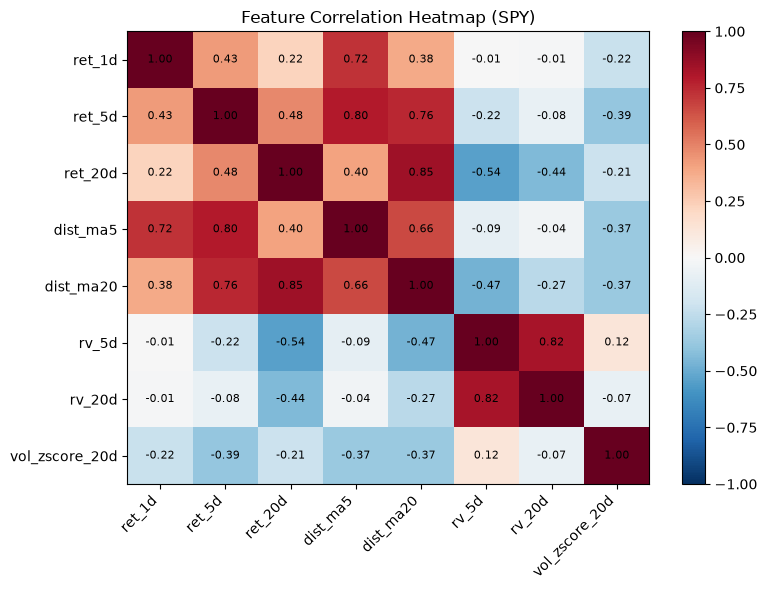

In [31]:
# Feature descriptive statistics
print('Feature Statistics (SPY):')
print(spy[FEATURE_COLS].describe().T.round(4))

# Feature correlation heatmap
corr = spy[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
plt.title('Feature Correlation Heatmap (SPY)')
plt.tight_layout()
plt.show()

## Phase 4: Market Regime Labeling

Compute annualized realized volatility:
```
RV(t) = sqrt(252) * Std[r(t-19), ..., r(t)]
```

Before each test quarter:
1. Compute 70th percentile of RV from all training data up to previous quarter end
2. Fix that threshold for the next test quarter
3. For each trading day in test quarter, compute RV(t)
4. RV(t) > threshold → high volatility; otherwise → low volatility

Note: `regime_t` label is assigned per day. The 20-day overlapping window causes adjacent days to share 19 days of data, so high-volatility days naturally cluster into continuous intervals.

In [32]:
def compute_regime_threshold(train_data, rv_col='rv_20d', percentile=70):
    """Compute RV percentile threshold from training data."""
    return np.percentile(train_data[rv_col].dropna(), percentile)


def label_regime(rv_series, threshold):
    """Label each day as high (1) or low (0) volatility."""
    return (rv_series > threshold).astype(int)


def generate_quarterly_dates(start, end):
    """Generate quarter start dates between start and end."""
    quarters = pd.date_range(start=start, end=end, freq='QS')
    return quarters


print(f'Quarter starts in test period: {len(generate_quarterly_dates(TEST_START, TEST_END))}')

Quarter starts in test period: 44


## Phase 5: Model Training

Train 4 models with quarterly expanding window:
1. **Majority-class baseline**
2. **L2-regularized Logistic Regression** (standardized features)
3. **Random Forest**
4. **XGBoost**

Expanding window schedule:
```
2005–2014 real data → predict 2015 Q1 each trading day
2005–2015 Q1 real data → predict 2015 Q2 each trading day
...
up to 2025 Q3 real data → predict 2025 Q4 each trading day
```

Annual tuning + quarterly refit strategy:
- At each year's Q1 start, tune hyperparameters via 3-fold time-series CV on current training window
- Remaining quarters reuse hyperparameters, only refit with expanded data

### 5.1 Hyperparameter Search Grid

In [35]:
# Small fixed grid for hyperparameter search
LR_PARAM_GRID = {
    'C': [0.01, 0.1, 1.0, 10.0],
}

RF_PARAM_GRID = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [5, 10],
}

XGB_PARAM_GRID = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8],
}

print('Hyperparameter grids ready.')

Hyperparameter grids ready.


### 5.2 Annual Hyperparameter Tuning

In [36]:
from sklearn.model_selection import ParameterGrid

def tune_model(model_class, param_grid, X_train, y_train, n_splits=3):
    """Time-series CV hyperparameter tuning using Balanced Accuracy."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_score = -np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = model_class(**params, random_state=RANDOM_STATE)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            scores.append(balanced_accuracy_score(y_val, y_pred))

        mean_score = np.mean(scores)
        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    return best_params, best_score

print('Tuning function ready.')

Tuning function ready.


### 5.3 Quarterly Expanding Window Training & Prediction

In [37]:
def run_expanding_window(df, asset_name, rv_col='rv_20d', rv_pct=70, save_path=None, log_path=None):
    """Run quarterly expanding window training and generate OOS predictions.

    Returns:
        results_df: DataFrame with columns
            [date, asset, regime, y_true, baseline_pred, lr_prob, rf_prob, xgb_prob]
    """
    quarters = generate_quarterly_dates(TEST_START, TEST_END)
    results = []
    training_log = []

    # Current best hyperparameters (updated annually)
    lr_params = {'C': 1.0}
    rf_params = {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 5}
    xgb_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}
    last_tune_year = None

    for i, q_start in enumerate(quarters):
        # Determine quarter end
        q_end = quarters[i + 1] - pd.Timedelta(days=1) if i + 1 < len(quarters) else pd.Timestamp(TEST_END)

        # Training data: all data up to previous quarter end
        train_end = q_start - pd.Timedelta(days=1)
        train_mask = df.index <= train_end
        test_mask = (df.index >= q_start) & (df.index <= q_end)

        train_data = df.loc[train_mask].copy()
        test_data = df.loc[test_mask].copy()

        if len(train_data) == 0 or len(test_data) == 0:
            continue

        X_train = train_data[FEATURE_COLS]
        y_train = train_data['label'].astype(int)
        X_test = test_data[FEATURE_COLS]
        y_test = test_data['label'].astype(int)

        # --- Regime labeling ---
        rv_threshold = compute_regime_threshold(train_data, rv_col, rv_pct)
        regime = label_regime(test_data[rv_col], rv_threshold)

        # --- Annual hyperparameter tuning ---
        current_year = q_start.year
        is_q1 = (q_start.month == 1)
        if is_q1 and current_year != last_tune_year:
            print(f'  Tuning hyperparameters for year {current_year}...')
            # Standardize for LR tuning
            scaler_tune = StandardScaler()
            X_train_scaled = pd.DataFrame(
                scaler_tune.fit_transform(X_train), index=X_train.index, columns=X_train.columns
            )
            lr_params, _ = tune_model(LogisticRegression, LR_PARAM_GRID, X_train_scaled, y_train)
            rf_params, _ = tune_model(RandomForestClassifier, RF_PARAM_GRID, X_train, y_train)
            xgb_params, _ = tune_model(
                XGBClassifier,
                XGB_PARAM_GRID,
                X_train, y_train
            )
            last_tune_year = current_year

        # --- Fit models ---
        # Standardize for LR
        scaler = StandardScaler()
        X_train_lr = pd.DataFrame(
            scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns
        )
        X_test_lr = pd.DataFrame(
            scaler.transform(X_test), index=X_test.index, columns=X_test.columns
        )

        # Majority-class baseline
        majority_class = int(y_train.mode().iloc[0])
        baseline_pred = majority_class  # constant prediction

        # Logistic Regression
        lr_model = LogisticRegression(**lr_params, random_state=RANDOM_STATE, max_iter=1000)
        lr_model.fit(X_train_lr, y_train)
        lr_prob = lr_model.predict_proba(X_test_lr)[:, 1]

        # Random Forest
        rf_model = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE)
        rf_model.fit(X_train, y_train)
        rf_prob = rf_model.predict_proba(X_test)[:, 1]

        # XGBoost
        xgb_model = XGBClassifier(
            **xgb_params, random_state=RANDOM_STATE,
            use_label_encoder=False, eval_metric='logloss'
        )
        xgb_model.fit(X_train, y_train)
        xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

        # --- Collect results ---
        for j in range(len(test_data)):
            results.append({
                'date': test_data.index[j],
                'asset': asset_name,
                'regime': regime.iloc[j],
                'y_true': y_test.iloc[j],
                'baseline_pred': baseline_pred,
                'lr_prob': lr_prob[j],
                'rf_prob': rf_prob[j],
                'xgb_prob': xgb_prob[j],
            })

        print(f'  {asset_name} {q_start.date()} ~ {q_end.date()}: '
              f'train={len(train_data)}, test={len(test_data)}, '
              f'regime_threshold={rv_threshold:.4f}')

        training_log.append({
            'asset': asset_name,
            'test_start': q_start,
            'test_end': q_end,
            'train_n': len(train_data),
            'test_n': len(test_data),
            'rv_col': rv_col,
            'rv_pct': rv_pct,
            'regime_threshold': rv_threshold,
            'lr_params': str(lr_params),
            'rf_params': str(rf_params),
            'xgb_params': str(xgb_params),
        })

    results_df = pd.DataFrame(results)

    if save_path is not None:
        results_df.to_csv(save_path, index=False)
    if log_path is not None:
        pd.DataFrame(training_log).to_csv(log_path, index=False)

    return results_df

print('Expanding window function defined.')

Expanding window function defined.


### 5.4 SPY Training Execute

In [38]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

spy_save_path = os.path.join(OUTPUT_DIR, 'spy_results.csv')
spy_log_path = os.path.join(OUTPUT_DIR, 'spy_training_log.csv')

if os.path.exists(spy_save_path):
    print('Loading cached SPY results...')
    spy_results = pd.read_csv(spy_save_path, parse_dates=['date'])
else:
    print('Running expanding window for SPY...')
    spy_results = run_expanding_window(
        spy, config['primary_asset'],
        save_path=spy_save_path, log_path=spy_log_path,
    )

print(f'\nSPY results shape: {spy_results.shape}')
spy_results.head()

Running expanding window for SPY...
  Tuning hyperparameters for year 2015...
  SPY 2015-01-01 ~ 2015-03-31: train=2497, test=61, regime_threshold=0.1721
  SPY 2015-04-01 ~ 2015-06-30: train=2558, test=63, regime_threshold=0.1708
  SPY 2015-07-01 ~ 2015-09-30: train=2621, test=64, regime_threshold=0.1684
  SPY 2015-10-01 ~ 2015-12-31: train=2685, test=64, regime_threshold=0.1695
  Tuning hyperparameters for year 2016...
  SPY 2016-01-01 ~ 2016-03-31: train=2749, test=61, regime_threshold=0.1697
  SPY 2016-04-01 ~ 2016-06-30: train=2810, test=64, regime_threshold=0.1724
  SPY 2016-07-01 ~ 2016-09-30: train=2874, test=64, regime_threshold=0.1708
  SPY 2016-10-01 ~ 2016-12-31: train=2938, test=63, regime_threshold=0.1706
  Tuning hyperparameters for year 2017...
  SPY 2017-01-01 ~ 2017-03-31: train=3001, test=62, regime_threshold=0.1684
  SPY 2017-04-01 ~ 2017-06-30: train=3063, test=63, regime_threshold=0.1673
  SPY 2017-07-01 ~ 2017-09-30: train=3126, test=63, regime_threshold=0.1654
  

,date,asset,regime,y_true,baseline_pred,lr_prob,rf_prob,xgb_prob
0,2015-01-02,SPY,0,0,1,0.509841,0.541509,0.524995
1,2015-01-05,SPY,0,0,1,0.524820,0.579175,0.520792
2,2015-01-06,SPY,0,1,1,0.515405,0.559745,0.603261
3,2015-01-07,SPY,1,1,1,0.510550,0.485788,0.343752
4,2015-01-08,SPY,1,0,1,0.527332,0.582517,0.583974


## Phase 6: Out-of-Sample Prediction Results

Unified result table with columns:

| date | asset | regime | y_true | baseline_pred | lr_prob | rf_prob | xgb_prob |
|---|---|---|---:|---:|---:|---:|---:|

This table is the **sole input** for subsequent evaluation and robustness analysis.

In [39]:
# Descriptive statistics of the result table
print(f'Total OOS predictions: {len(spy_results)}')
print(f'Date range: {spy_results["date"].min().date()} ~ {spy_results["date"].max().date()}')
print(f'\nRegime distribution:')
regime_counts = spy_results['regime'].value_counts().sort_index()
for regime, count in regime_counts.items():
    label = 'Low Vol' if regime == 0 else 'High Vol'
    print(f'  {label}: {count} ({count/len(spy_results):.1%})')

print(f'\nLabel distribution:')
label_counts = spy_results['y_true'].value_counts().sort_index()
for lab, count in label_counts.items():
    direction = 'Down/Flat' if lab == 0 else 'Up'
    print(f'  {direction}: {count} ({count/len(spy_results):.1%})')

Total OOS predictions: 2765
Date range: 2015-01-02 ~ 2025-12-30

Regime distribution:
  Low Vol: 1969 (71.2%)
  High Vol: 796 (28.8%)

Label distribution:
  Down/Flat: 1278 (46.2%)
  Up: 1487 (53.8%)


## Phase 7: Main Results Evaluation

Evaluate on three sample scopes:
1. All out-of-sample test data
2. Low volatility samples
3. High volatility samples

Two metrics:
- **Balanced Accuracy** (primary)
- **ROC-AUC** (secondary)

Stability measure:
```
Delta_BA(m) = BA(m, high) - BA(m, low)
```

### 7.1 Evaluation Functions

In [40]:
def evaluate_model(y_true, y_prob, model_name, threshold=0.5):
    """Compute Balanced Accuracy and ROC-AUC for a model."""
    y_pred = (y_prob >= threshold).astype(int)
    ba = balanced_accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan
    return {'model': model_name, 'balanced_accuracy': ba, 'roc_auc': auc}


def evaluate_baseline(y_true, baseline_pred, model_name='Baseline'):
    """Evaluate majority-class baseline.
    baseline_pred 可以是标量或与 y_true 等长的数组（逐行比较）。
    """
    y_pred = np.asarray(baseline_pred)
    if y_pred.ndim == 0:
        y_pred = np.full(len(y_true), y_pred)
    ba = balanced_accuracy_score(y_true, y_pred)
    return {'model': model_name, 'balanced_accuracy': ba, 'roc_auc': np.nan}


def evaluate_all_models(results_df, scope_name='All'):
    """Evaluate all 4 models on given result subset."""
    y_true = results_df['y_true']
    rows = []
    # Baseline: 逐行比较每个测试日的 baseline 预测值，而不是取 iloc[0]。
    # 因为 baseline_pred 是按季度取训练集多数类，不同季度可能不同，抽单一标量会误判。
    rows.append(evaluate_baseline(y_true, results_df['baseline_pred']))
    # LR, RF, XGB
    for col, name in [('lr_prob', 'LogisticRegression'), ('rf_prob', 'RandomForest'), ('xgb_prob', 'XGBoost')]:
        rows.append(evaluate_model(y_true, results_df[col], name))
    eval_df = pd.DataFrame(rows)
    eval_df['scope'] = scope_name
    return eval_df

print('Evaluation functions defined.')

Evaluation functions defined.


### 7.2 Main Results Table

In [41]:
# Evaluate on three scopes
eval_all = evaluate_all_models(spy_results, 'All')
eval_low = evaluate_all_models(spy_results[spy_results['regime'] == 0], 'Low Vol')
eval_high = evaluate_all_models(spy_results[spy_results['regime'] == 1], 'High Vol')

main_results = pd.concat([eval_all, eval_low, eval_high], ignore_index=True)
print('Main Results (SPY):')
print(main_results.to_string(index=False))

Main Results (SPY):
             model  balanced_accuracy  roc_auc    scope
          Baseline           0.500000      NaN      All
LogisticRegression           0.496832 0.505308      All
      RandomForest           0.501467 0.503505      All
           XGBoost           0.504699 0.509241      All
          Baseline           0.500000      NaN  Low Vol
LogisticRegression           0.500080 0.526702  Low Vol
      RandomForest           0.500504 0.504841  Low Vol
           XGBoost           0.505981 0.513556  Low Vol
          Baseline           0.500000      NaN High Vol
LogisticRegression           0.488153 0.461557 High Vol
      RandomForest           0.503580 0.500162 High Vol
           XGBoost           0.500809 0.499363 High Vol


### 7.3 Delta_BA & Bootstrap Confidence Interval

In [42]:
def moving_block_bootstrap_delta_ba(results_df, model_prob_col, n_boot=1000, block_size=20, alpha=0.05):
    """Moving block bootstrap for Delta_BA = BA(high) - BA(low).

    Preserves short-range temporal dependence in financial time series.
    """
    rng = np.random.RandomState(RANDOM_STATE)
    n = len(results_df)
    delta_ba_samples = []

    for _ in range(n_boot):
        # Draw overlapping blocks
        indices = []
        while len(indices) < n:
            start = rng.randint(0, n - block_size + 1)
            indices.extend(range(start, start + block_size))
        indices = indices[:n]

        boot_df = results_df.iloc[indices].reset_index(drop=True)

        high_mask = boot_df['regime'] == 1
        low_mask = boot_df['regime'] == 0

        if high_mask.sum() < 5 or low_mask.sum() < 5:
            continue

        y_pred_high = (boot_df.loc[high_mask, model_prob_col] >= 0.5).astype(int)
        y_pred_low = (boot_df.loc[low_mask, model_prob_col] >= 0.5).astype(int)

        ba_high = balanced_accuracy_score(boot_df.loc[high_mask, 'y_true'], y_pred_high)
        ba_low = balanced_accuracy_score(boot_df.loc[low_mask, 'y_true'], y_pred_low)

        delta_ba_samples.append(ba_high - ba_low)

    delta_ba_samples = np.array(delta_ba_samples)
    ci_low = np.percentile(delta_ba_samples, 100 * alpha / 2)
    ci_high = np.percentile(delta_ba_samples, 100 * (1 - alpha / 2))
    point_est = np.mean(delta_ba_samples)

    return point_est, ci_low, ci_high


# Compute Delta_BA for each model
print('Delta_BA (95% CI) for SPY:')
delta_results = []
for col, name in [('lr_prob', 'LogisticRegression'), ('rf_prob', 'RandomForest'), ('xgb_prob', 'XGBoost')]:
    point, ci_lo, ci_hi = moving_block_bootstrap_delta_ba(spy_results, col)
    sig = '*' if ci_lo > 0 or ci_hi < 0 else ''
    delta_results.append({'model': name, 'delta_ba': point, 'ci_low': ci_lo, 'ci_high': ci_hi, 'significant': sig})
    print(f'  {name:25s}: Delta_BA={point:+.4f}  95% CI=[{ci_lo:+.4f}, {ci_hi:+.4f}] {sig}')

delta_df = pd.DataFrame(delta_results)
delta_df['check'] = 'Main_RV20_P70'

Delta_BA (95% CI) for SPY:
  LogisticRegression       : Delta_BA=-0.0109  95% CI=[-0.0311, +0.0080] 
  RandomForest             : Delta_BA=+0.0039  95% CI=[-0.0246, +0.0327] 
  XGBoost                  : Delta_BA=-0.0025  95% CI=[-0.0386, +0.0343] 


### 7.4 Delta_BA Visualization

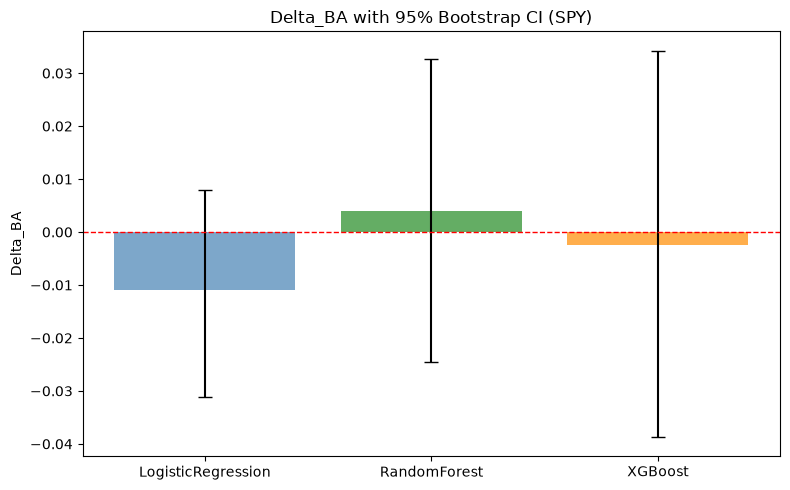

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
models = delta_df['model']
x = np.arange(len(models))
ax.bar(x, delta_df['delta_ba'], color=['steelblue', 'forestgreen', 'darkorange'], alpha=0.7)
ax.errorbar(x, delta_df['delta_ba'],
            yerr=[delta_df['delta_ba'] - delta_df['ci_low'],
                  delta_df['ci_high'] - delta_df['delta_ba']],
            fmt='none', ecolor='black', capsize=5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Delta_BA')
ax.set_title('Delta_BA with 95% Bootstrap CI (SPY)')
plt.tight_layout()
plt.show()

## Phase 8: Robustness Checks

Three robustness tests:

### 8.1 Alternative Market Regime Definitions
- 20-day RV with 80th percentile
- 60-day RV with 70th percentile

In [44]:
def add_rv_column(df, window, col_name):
    """Add a realized volatility column with specified window."""
    log_ret = np.log(df['close'] / df['close'].shift(1))
    df[col_name] = log_ret.rolling(window).std() * ANNUALIZE_FACTOR
    return df

# Add 60-day RV column for robustness check
spy = add_rv_column(spy, 60, 'rv_60d')

# Robustness 1a: 20-day RV, 80th percentile
robust_1a_path = os.path.join(OUTPUT_DIR, 'spy_robust_1a.csv')
if os.path.exists(robust_1a_path):
    print('Loading cached Robustness 1a (RV20, P80)...')
    spy_robust_1a = pd.read_csv(robust_1a_path, parse_dates=['date'])
else:
    print('Robustness 1a: RV20, P80')
    spy_robust_1a = run_expanding_window(spy, 'SPY', rv_col='rv_20d', rv_pct=80, save_path=robust_1a_path)

# Robustness 1b: 60-day RV, 70th percentile
robust_1b_path = os.path.join(OUTPUT_DIR, 'spy_robust_1b.csv')
if os.path.exists(robust_1b_path):
    print('Loading cached Robustness 1b (RV60, P70)...')
    spy_robust_1b = pd.read_csv(robust_1b_path, parse_dates=['date'])
else:
    print('\nRobustness 1b: RV60, P70')
    # 用独立副本删除 rv_60d 的 NaN（前 59 天），避免原地修改 spy 而污染后续 Phase 8.3 滚动窗口等代码。
    spy_rv60 = spy.dropna(subset=['rv_60d']).copy()
    spy_robust_1b = run_expanding_window(spy_rv60, 'SPY', rv_col='rv_60d', rv_pct=70, save_path=robust_1b_path)

Robustness 1a: RV20, P80
  Tuning hyperparameters for year 2015...
  SPY 2015-01-01 ~ 2015-03-31: train=2497, test=61, regime_threshold=0.2069
  SPY 2015-04-01 ~ 2015-06-30: train=2558, test=63, regime_threshold=0.2062
  SPY 2015-07-01 ~ 2015-09-30: train=2621, test=64, regime_threshold=0.2044
  SPY 2015-10-01 ~ 2015-12-31: train=2685, test=64, regime_threshold=0.2061
  Tuning hyperparameters for year 2016...
  SPY 2016-01-01 ~ 2016-03-31: train=2749, test=61, regime_threshold=0.2045
  SPY 2016-04-01 ~ 2016-06-30: train=2810, test=64, regime_threshold=0.2058
  SPY 2016-07-01 ~ 2016-09-30: train=2874, test=64, regime_threshold=0.2046
  SPY 2016-10-01 ~ 2016-12-31: train=2938, test=63, regime_threshold=0.2030
  Tuning hyperparameters for year 2017...
  SPY 2017-01-01 ~ 2017-03-31: train=3001, test=62, regime_threshold=0.2010
  SPY 2017-04-01 ~ 2017-06-30: train=3063, test=63, regime_threshold=0.1999
  SPY 2017-07-01 ~ 2017-09-30: train=3126, test=63, regime_threshold=0.1984
  SPY 2017-10

#### Alternative Regime Results

In [45]:
# Evaluate alternative regime definitions
def delta_ba_summary(results_df, label):
    """Compute Delta_BA + bootstrap CI for all three models, return a DataFrame."""
    rows = []
    for col, name in [('lr_prob', 'LogisticRegression'), ('rf_prob', 'RandomForest'), ('xgb_prob', 'XGBoost')]:
        point, ci_lo, ci_hi = moving_block_bootstrap_delta_ba(results_df, col)
        sig = '*' if ci_lo > 0 or ci_hi < 0 else ''
        rows.append({'model': name, 'delta_ba': point, 'ci_low': ci_lo, 'ci_high': ci_hi, 'significant': sig})
        print(f'  {name:25s}: Delta_BA={point:+.4f}  95% CI=[{ci_lo:+.4f}, {ci_hi:+.4f}] {sig}')
    summary = pd.DataFrame(rows)
    summary['check'] = label
    return summary

print('--- Robustness 1a: RV20, P80 ---')
robust_1a_df = delta_ba_summary(spy_robust_1a, 'RV20_P80')

print('\n--- Robustness 1b: RV60, P70 ---')
robust_1b_df = delta_ba_summary(spy_robust_1b, 'RV60_P70')

--- Robustness 1a: RV20, P80 ---
  LogisticRegression       : Delta_BA=-0.0208  95% CI=[-0.0481, +0.0073] 
  RandomForest             : Delta_BA=+0.0112  95% CI=[-0.0206, +0.0442] 
  XGBoost                  : Delta_BA=-0.0053  95% CI=[-0.0504, +0.0373] 

--- Robustness 1b: RV60, P70 ---
  LogisticRegression       : Delta_BA=-0.0034  95% CI=[-0.0205, +0.0117] 
  RandomForest             : Delta_BA=-0.0032  95% CI=[-0.0308, +0.0251] 
  XGBoost                  : Delta_BA=-0.0049  95% CI=[-0.0429, +0.0328] 


### 8.2 QQQ External Replication

Use identical features, labels, models, time splits, regime definition, and evaluation metrics.

In [46]:
qqq_save_path = os.path.join(OUTPUT_DIR, 'qqq_results.csv')
qqq_log_path = os.path.join(OUTPUT_DIR, 'qqq_training_log.csv')
if os.path.exists(qqq_save_path):
    print('Loading cached QQQ results...')
    qqq_results = pd.read_csv(qqq_save_path, parse_dates=['date'])
else:
    print('Running expanding window for QQQ...')
    qqq_results = run_expanding_window(
        qqq, config['validation_asset'],
        save_path=qqq_save_path, log_path=qqq_log_path,
    )

# QQQ main results
eval_all_qqq = evaluate_all_models(qqq_results, 'All')
eval_low_qqq = evaluate_all_models(qqq_results[qqq_results['regime'] == 0], 'Low Vol')
eval_high_qqq = evaluate_all_models(qqq_results[qqq_results['regime'] == 1], 'High Vol')

qqq_main_results = pd.concat([eval_all_qqq, eval_low_qqq, eval_high_qqq], ignore_index=True)
print('\nQQQ Main Results:')
print(qqq_main_results.to_string(index=False))

# QQQ Delta_BA
print('\nDelta_BA (95% CI) for QQQ:')
qqq_delta_df = delta_ba_summary(qqq_results, 'QQQ')

Running expanding window for QQQ...
  Tuning hyperparameters for year 2015...
  QQQ 2015-01-01 ~ 2015-03-31: train=2497, test=61, regime_threshold=0.2002
  QQQ 2015-04-01 ~ 2015-06-30: train=2558, test=63, regime_threshold=0.1980
  QQQ 2015-07-01 ~ 2015-09-30: train=2621, test=64, regime_threshold=0.1953
  QQQ 2015-10-01 ~ 2015-12-31: train=2685, test=64, regime_threshold=0.1965
  Tuning hyperparameters for year 2016...
  QQQ 2016-01-01 ~ 2016-03-31: train=2749, test=61, regime_threshold=0.1953
  QQQ 2016-04-01 ~ 2016-06-30: train=2810, test=64, regime_threshold=0.1984
  QQQ 2016-07-01 ~ 2016-09-30: train=2874, test=64, regime_threshold=0.1965
  QQQ 2016-10-01 ~ 2016-12-31: train=2938, test=63, regime_threshold=0.1963
  Tuning hyperparameters for year 2017...
  QQQ 2017-01-01 ~ 2017-03-31: train=3001, test=62, regime_threshold=0.1943
  QQQ 2017-04-01 ~ 2017-06-30: train=3063, test=63, regime_threshold=0.1926
  QQQ 2017-07-01 ~ 2017-09-30: train=3126, test=63, regime_threshold=0.1909
  

### 8.3 Rolling Training Window (5-Year Fixed)

Replace the expanding training window with a fixed 5-year rolling window to check whether the main results are driven by including too much stale historical data.

In [47]:
def run_rolling_window(df, asset_name, window_years=5, rv_col='rv_20d', rv_pct=70, save_path=None):
    """Run quarterly rolling (fixed-length) window training and generate OOS predictions."""
    quarters = generate_quarterly_dates(TEST_START, TEST_END)
    results = []

    lr_params = {'C': 1.0}
    rf_params = {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 5}
    xgb_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}
    last_tune_year = None

    for i, q_start in enumerate(quarters):
        q_end = quarters[i + 1] - pd.Timedelta(days=1) if i + 1 < len(quarters) else pd.Timestamp(TEST_END)

        # Rolling window: last N years before quarter start
        train_end = q_start - pd.Timedelta(days=1)
        train_start = train_end - pd.DateOffset(years=window_years)
        train_mask = (df.index >= train_start) & (df.index <= train_end)
        test_mask = (df.index >= q_start) & (df.index <= q_end)

        train_data = df.loc[train_mask].copy()
        test_data = df.loc[test_mask].copy()

        if len(train_data) == 0 or len(test_data) == 0:
            continue

        X_train = train_data[FEATURE_COLS]
        y_train = train_data['label'].astype(int)
        X_test = test_data[FEATURE_COLS]
        y_test = test_data['label'].astype(int)

        rv_threshold = compute_regime_threshold(train_data, rv_col, rv_pct)
        regime = label_regime(test_data[rv_col], rv_threshold)

        current_year = q_start.year
        is_q1 = (q_start.month == 1)
        if is_q1 and current_year != last_tune_year:
            scaler_tune = StandardScaler()
            X_train_scaled = pd.DataFrame(
                scaler_tune.fit_transform(X_train), index=X_train.index, columns=X_train.columns
            )
            lr_params, _ = tune_model(LogisticRegression, LR_PARAM_GRID, X_train_scaled, y_train)
            rf_params, _ = tune_model(RandomForestClassifier, RF_PARAM_GRID, X_train, y_train)
            xgb_params, _ = tune_model(XGBClassifier, XGB_PARAM_GRID, X_train, y_train)
            last_tune_year = current_year

        scaler = StandardScaler()
        X_train_lr = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test_lr = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

        majority_class = int(y_train.mode().iloc[0])

        lr_model = LogisticRegression(**lr_params, random_state=RANDOM_STATE, max_iter=1000)
        lr_model.fit(X_train_lr, y_train)
        lr_prob = lr_model.predict_proba(X_test_lr)[:, 1]

        rf_model = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE)
        rf_model.fit(X_train, y_train)
        rf_prob = rf_model.predict_proba(X_test)[:, 1]

        xgb_model = XGBClassifier(**xgb_params, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')
        xgb_model.fit(X_train, y_train)
        xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

        for j in range(len(test_data)):
            results.append({
                'date': test_data.index[j],
                'asset': asset_name,
                'regime': regime.iloc[j],
                'y_true': y_test.iloc[j],
                'baseline_pred': majority_class,
                'lr_prob': lr_prob[j],
                'rf_prob': rf_prob[j],
                'xgb_prob': xgb_prob[j],
            })

        print(f'  {asset_name} {q_start.date()} ~ {q_end.date()}: '
              f'train={len(train_data)}, test={len(test_data)}')

    results_df = pd.DataFrame(results)
    if save_path is not None:
        results_df.to_csv(save_path, index=False)
    return results_df


print('Running 5-year rolling window for SPY...')
rolling_save_path = os.path.join(OUTPUT_DIR, 'spy_rolling_results.csv')
if os.path.exists(rolling_save_path):
    print('Loading cached rolling results...')
    spy_rolling_results = pd.read_csv(rolling_save_path, parse_dates=['date'])
else:
    spy_rolling_results = run_rolling_window(spy, 'SPY_rolling', save_path=rolling_save_path)

# Evaluate
print('\n5-Year Rolling Window Results:')
eval_all_roll = evaluate_all_models(spy_rolling_results, 'All')
eval_low_roll = evaluate_all_models(spy_rolling_results[spy_rolling_results['regime'] == 0], 'Low Vol')
eval_high_roll = evaluate_all_models(spy_rolling_results[spy_rolling_results['regime'] == 1], 'High Vol')

rolling_results = pd.concat([eval_all_roll, eval_low_roll, eval_high_roll], ignore_index=True)
print(rolling_results.to_string(index=False))

print('\nDelta_BA (95% CI) for 5-Year Rolling:')
rolling_delta_df = delta_ba_summary(spy_rolling_results, '5Y_Rolling')

Running 5-year rolling window for SPY...
  SPY_rolling 2015-01-01 ~ 2015-03-31: train=1259, test=61
  SPY_rolling 2015-04-01 ~ 2015-06-30: train=1259, test=63
  SPY_rolling 2015-07-01 ~ 2015-09-30: train=1259, test=64
  SPY_rolling 2015-10-01 ~ 2015-12-31: train=1259, test=64
  SPY_rolling 2016-01-01 ~ 2016-03-31: train=1259, test=61
  SPY_rolling 2016-04-01 ~ 2016-06-30: train=1258, test=64
  SPY_rolling 2016-07-01 ~ 2016-09-30: train=1259, test=64
  SPY_rolling 2016-10-01 ~ 2016-12-31: train=1259, test=63
  SPY_rolling 2017-01-01 ~ 2017-03-31: train=1258, test=62
  SPY_rolling 2017-04-01 ~ 2017-06-30: train=1258, test=63
  SPY_rolling 2017-07-01 ~ 2017-09-30: train=1258, test=63
  SPY_rolling 2017-10-01 ~ 2017-12-31: train=1258, test=63
  SPY_rolling 2018-01-01 ~ 2018-03-31: train=1260, test=61
  SPY_rolling 2018-04-01 ~ 2018-06-30: train=1260, test=64
  SPY_rolling 2018-07-01 ~ 2018-09-30: train=1260, test=63
  SPY_rolling 2018-10-01 ~ 2018-12-31: train=1260, test=63
  SPY_rolling 2

## Final Output Summary

### Output 1: Descriptive Statistics (Sample & Regime)

In [48]:
# Descriptive statistics table
def descriptive_stats(results_df, asset):
    """Generate descriptive statistics table for sample and regime."""
    total = len(results_df)
    low_mask = results_df['regime'] == 0
    high_mask = results_df['regime'] == 1

    stats = pd.DataFrame({
        'Scope': ['All', 'Low Vol', 'High Vol'],
        'N': [total, low_mask.sum(), high_mask.sum()],
        'Pct_Up': [
            results_df['y_true'].mean(),
            results_df.loc[low_mask, 'y_true'].mean(),
            results_df.loc[high_mask, 'y_true'].mean()
        ],
    })
    stats['Asset'] = asset
    return stats

desc_spy = descriptive_stats(spy_results, 'SPY')
print('Descriptive Statistics (SPY):')
print(desc_spy.to_string(index=False))

Descriptive Statistics (SPY):
   Scope    N   Pct_Up Asset
     All 2765 0.537794   SPY
 Low Vol 1969 0.539360   SPY
High Vol  796 0.533920   SPY


### Output 2: Main Results Table (All, High Vol, Low Vol)

In [49]:
print('Main Results - Balanced Accuracy (SPY):')
pivot_ba = main_results.pivot(index='model', columns='scope', values='balanced_accuracy')
print(pivot_ba.round(4).to_string())

print('\nMain Results - ROC-AUC (SPY):')
pivot_auc = main_results.pivot(index='model', columns='scope', values='roc_auc')
print(pivot_auc.round(4).to_string())

Main Results - Balanced Accuracy (SPY):
scope                  All  High Vol  Low Vol
model                                        
Baseline            0.5000    0.5000   0.5000
LogisticRegression  0.4968    0.4882   0.5001
RandomForest        0.5015    0.5036   0.5005
XGBoost             0.5047    0.5008   0.5060

Main Results - ROC-AUC (SPY):
scope                  All  High Vol  Low Vol
model                                        
Baseline               NaN       NaN      NaN
LogisticRegression  0.5053    0.4616   0.5267
RandomForest        0.5035    0.5002   0.5048
XGBoost             0.5092    0.4994   0.5136


### Output 3: Delta_BA with 95% CI (already plotted in Phase 7.4)

### Output 4: Alternative Regime Robustness Table

In [50]:
# Combine all Delta_BA results (main + 1a/1b + QQQ + rolling) into one wide table
delta_all = pd.concat([delta_df, robust_1a_df, robust_1b_df, qqq_delta_df, rolling_delta_df],
                      ignore_index=True)
delta_wide = delta_all.pivot(index='model', columns='check', values='delta_ba')
delta_wide = delta_wide[['Main_RV20_P70', 'RV20_P80', 'RV60_P70', 'QQQ', '5Y_Rolling']]
print('Delta_BA Summary Across Robustness Checks:')
print(delta_wide.round(4).to_string())

Delta_BA Summary Across Robustness Checks:
check               Main_RV20_P70  RV20_P80  RV60_P70     QQQ  5Y_Rolling
model                                                                    
LogisticRegression        -0.0109   -0.0208   -0.0034 -0.0134     -0.0006
RandomForest               0.0039    0.0112   -0.0032 -0.0147     -0.0067
XGBoost                   -0.0025   -0.0053   -0.0049  0.0015     -0.0053


### Output 5: QQQ External Replication Table

In [51]:
print('QQQ Replication - Balanced Accuracy:')
qqq_ba = qqq_main_results.pivot(index='model', columns='scope', values='balanced_accuracy')
print(qqq_ba.round(4).to_string())

QQQ Replication - Balanced Accuracy:
scope                  All  High Vol  Low Vol
model                                        
Baseline            0.5000    0.5000   0.5000
LogisticRegression  0.4959    0.4866   0.5002
RandomForest        0.4942    0.4837   0.4998
XGBoost             0.4924    0.4924   0.4925


### Output 6: 5-Year Rolling Window Table

In [52]:
print('5-Year Rolling Window - Balanced Accuracy:')
rolling_ba = rolling_results.pivot(index='model', columns='scope', values='balanced_accuracy')
print(rolling_ba.round(4).to_string())

5-Year Rolling Window - Balanced Accuracy:
scope                  All  High Vol  Low Vol
model                                        
Baseline            0.5000    0.5000   0.5000
LogisticRegression  0.5033    0.5028   0.5037
RandomForest        0.4968    0.4910   0.4994
XGBoost             0.4956    0.4915   0.4975


## Conclusion

### Project Completion Criteria

- [ ] No future information leakage in data processing
- [ ] All three models completed 2015–2025 OOS one-step predictions via quarterly expanding window
- [ ] Each test quarter uses only real data up to previous quarter end for refitting
- [ ] All models share unified features and test samples
- [ ] Delta_BA (high vs. low volatility) statistically tested
- [ ] All three robustness checks completed
- [ ] SPY main results and QQQ external validation both have clear conclusions

The focus is **not** finding the most accurate model, but determining whether different learning paradigms exhibit **market-regime-dependent** prediction ability.